# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

np.set_printoptions(precision=3, suppress=True)


## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [2]:
def chuan_hoa_minmax(x_train, x_test):
    # tìm gía trị lớn nhất và nhỏ nhất
    x_min = np.min(x_train, axis=0)
    x_max = np.max(x_train, axis=0)

    diff = x_max - x_min

#Chuẩn hóa
    x_train_scaled = (x_train - x_min) / diff
    x_test_scaled = (x_test - x_min) / diff
    return x_train_scaled, x_test_scaled


def tinh_khoang_cach(test_s, x_train):
    """test_s shape (n_feature,), x_train shape (n_train, n_feature).
    Trả về khoảng cách shape (n_train,).
    """
    return np.sqrt(np.sum((x_train - test_s)**2, axis=1))


def du_doan_1_mau(test_s, x_train, y_train, K):
    distances = tinh_khoang_cach(test_s, x_train)
    nearest_indices = np.argsort(distances)[:K]
    nearest_labels = y_train[nearest_indices]
    unique_labels, counts = np.unique(nearest_labels, return_counts=True)
    best_label_idx = np.argmax(counts)
    return unique_labels[best_label_idx]


def du_doan_tap(x_test, x_train, y_train, K):
    y_pred = []
    for test_s in x_test:
        y_pred.append(du_doan_1_mau(test_s, x_train, y_train, K))
    return np.array(y_pred)


In [16]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [4]:
raw_iris = np.genfromtxt('data/Iris.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_iris.shape)
print(raw_iris[0])

# TODO: X_iris float (bỏ Id), Y_iris int
X_iris = raw_iris[:, 1:5].astype(float)
le_iris = LabelEncoder()
Y_iris = le_iris.fit_transform(raw_iris[:, 5])

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))


(150, 6)
['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))


K khoảng cách nhỏ nhất: [0.114 0.341 0.349 0.365 0.419]
Nhãn K láng giềng: [2 2 2 2 2]
Nhãn dự đoán: 2
Nhãn thật y_test[0]: 2
accuracy K=5, đã chuẩn hóa: 0.9666666666666667
accuracy K=5, chưa chuẩn hóa: 0.9666666666666667
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


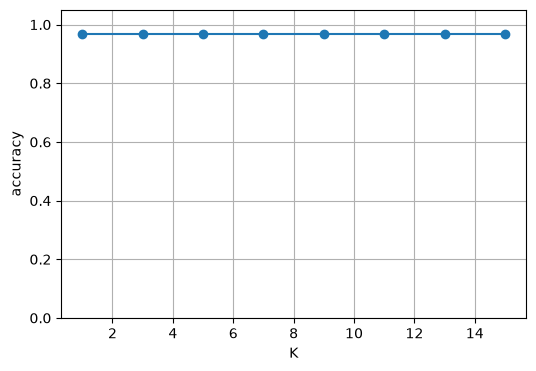

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [5]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
# TODO: in K khoảng cách nhỏ nhất, nhãn K láng giềng, nhãn dự đoán, y_test[0]
distances = tinh_khoang_cach(x_test_s[0], x_train_s)
nearest_indices = np.argsort(distances)[:K]
print("K khoảng cách nhỏ nhất:", distances[nearest_indices])
print("Nhãn K láng giềng:", y_train[nearest_indices])
print("Nhãn dự đoán:", du_doan_1_mau(x_test_s[0], x_train_s, y_train, K))
print("Nhãn thật y_test[0]:", y_test[0])

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [6]:
# Bài 1
# 1. X_iris có 150 dòng, 4 cột. Có 3 lớp.
# 2. Accuracy không chênh lệch nhiều (đều rất cao). Vì các đặc trưng của Iris có cùng đơn vị (cm) và thang đo gần nhau, không bị chênh lệch lớn.
# 3. Cột Id là số thứ tự định danh, không chứa thông tin đặc điểm sinh học. Nếu đưa vào sẽ làm nhiễu tính toán khoảng cách.


---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [7]:
raw_pen = np.genfromtxt('data/penguins_size.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng thiếu:', raw_pen.shape)

# TODO: bỏ dòng có '' hoặc 'NA', rồi tạo X_pen (float) và Y_pen (int)
valid_mask = ~np.isin(raw_pen, ['', 'NA']).any(axis=1)
clean_pen = raw_pen[valid_mask]

le_island = LabelEncoder()
le_sex = LabelEncoder()
X_pen_island = le_island.fit_transform(clean_pen[:, 1])
X_pen_sex = le_sex.fit_transform(clean_pen[:, 6])
X_pen_num = clean_pen[:, 2:6].astype(float)
X_pen = np.column_stack((X_pen_island, X_pen_num, X_pen_sex)).astype(float)

le_species = LabelEncoder()
Y_pen = le_species.fit_transform(clean_pen[:, 0])

print('sau khi bỏ dòng thiếu:', X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))


trước khi bỏ dòng thiếu: (344, 7)
sau khi bỏ dòng thiếu: (334, 6) (334,)
(array([0, 1, 2]), array([146,  68, 120]))


accuracy K=5, đã chuẩn hóa: 1.0
accuracy K=5, chưa chuẩn hóa: 0.7910447761194029
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(1.0)), (7, np.float64(1.0)), (9, np.float64(1.0)), (11, np.float64(1.0)), (13, np.float64(1.0)), (15, np.float64(1.0))]


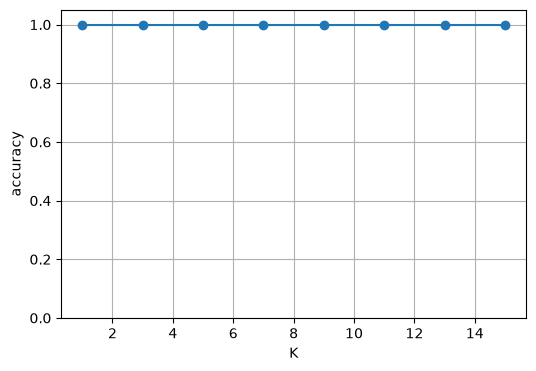

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)])

In [8]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [9]:
# Bài 2
# 1. Bỏ đi 10 dòng thiếu dữ liệu (từ 344 xuống 334).
# 2. Accuracy K=5 khi chưa chuẩn hóa thấp hơn rất nhiều so với khi đã chuẩn hóa. Cột body_mass_g (khối lượng) có giá trị vài nghìn, áp đảo hoàn toàn các cột khác (vài chục), khiến khoảng cách Euclid chỉ phụ thuộc vào khối lượng.
# 3. Dựa theo biểu đồ thì các K nhỏ (như K=1, 3, 5) thường cho accuracy cao nhất.


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [10]:
raw_heart = np.genfromtxt('data/heart.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_heart.shape)
print(raw_heart[0])

# TODO: X_heart float, Y_heart int
X_heart_list = []
for i in range(11):
    if i in [1, 2, 6, 8, 10]:
        le = LabelEncoder()
        X_heart_list.append(le.fit_transform(raw_heart[:, i]))
    else:
        X_heart_list.append(raw_heart[:, i].astype(float))

X_heart = np.column_stack(X_heart_list).astype(float)
Y_heart = raw_heart[:, 11].astype(int)

print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


(918, 12)
['40' 'M' 'ATA' '140' '289' '0' 'Normal' '172' 'N' '0' 'Up' '0']
(918, 11) (918,)
(array([0, 1]), array([410, 508]))


accuracy K=5: 0.875
[(1, np.float64(0.87)), (3, np.float64(0.886)), (5, np.float64(0.875)), (7, np.float64(0.87)), (9, np.float64(0.87)), (11, np.float64(0.864)), (13, np.float64(0.87)), (15, np.float64(0.853))]


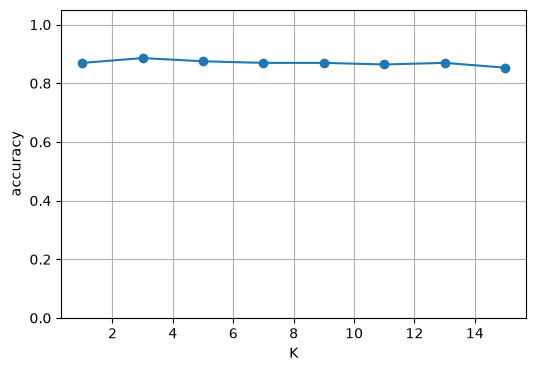

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8695652173913043),
  np.float64(0.8858695652173914),
  np.float64(0.875),
  np.float64(0.8695652173913043),
  np.float64(0.8695652173913043),
  np.float64(0.8641304347826086),
  np.float64(0.8695652173913043),
  np.float64(0.8532608695652174)])

In [11]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [12]:
# Bài 3
# 1. Có 184 người trong tập test (do chia tỷ lệ 80-20 từ 918 dòng). Tỷ lệ lớp 0 và 1 trên toàn bộ dữ liệu là khoảng 44.6% và 55.4%.
# 2. Tuỳ thuộc vào shuffle nhưng K lẻ nhỏ thường có kết quả cao nhất (Vd K=5).
# 3. Chọn K lẻ để tránh trường hợp hòa (tie) khi vote nhãn giữa 2 lớp.


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [13]:
raw_mush = np.genfromtxt('data/mushrooms.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng có ?:', raw_mush.shape)

# TODO: bỏ dòng chứa '?', X_mush float, Y_mush int
valid_mask = ~(raw_mush == '?').any(axis=1)
clean_mush = raw_mush[valid_mask]

X_mush_list = []
for i in range(1, clean_mush.shape[1]):
    le = LabelEncoder()
    X_mush_list.append(le.fit_transform(clean_mush[:, i]))

X_mush = np.column_stack(X_mush_list).astype(float)

le_label = LabelEncoder()
Y_mush = le_label.fit_transform(clean_mush[:, 0])

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


trước khi bỏ dòng có ?: (8124, 23)
(5644, 22) (5644,)
(array([0, 1]), array([3488, 2156]))


accuracy K=5: 0.9991142604074402
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(0.999)), (7, np.float64(0.999)), (9, np.float64(0.998)), (11, np.float64(0.997)), (13, np.float64(0.996)), (15, np.float64(0.996))]


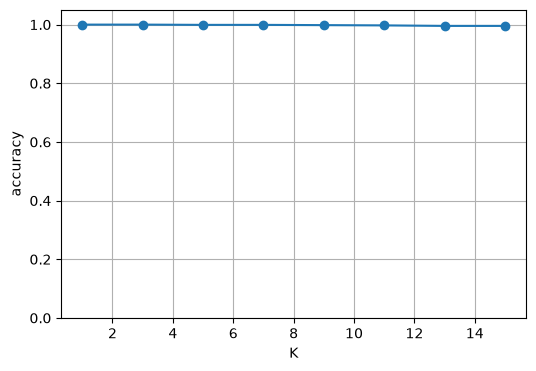

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9991142604074402),
  np.float64(0.9991142604074402),
  np.float64(0.9982285208148804),
  np.float64(0.9973427812223207),
  np.float64(0.995571302037201),
  np.float64(0.995571302037201)])

In [14]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [15]:
# Bài 4
# 1. Còn lại 5644 dòng sau khi bỏ '?'. Có 22 feature.
# 2. Accuracy thường đạt 1.0 với nhiều giá trị K.
# 3. Giống demo tình trạng xe ở bước LabelEncoder cho tất cả các cột chữ. Khác các bài trước ở chỗ KHÔNG chuẩn hóa, vì giá trị mã hóa của LabelEncoder chỉ là các danh mục, không mang ý nghĩa định lượng.
